# 90 - Autoencoders and Occlusion

**Section:** Autoencoders | **Prereqs:** `Autoencoders/DenoisingMNIST.ipynb` | **Next:** `Autoencoders/Latent_Code_Of_MNIST.ipynb`

Same architecture as the denoising notebook, a harder corruption: instead of
scattered noise, three whole rows of the image are set to white.

**Why occlusion is harder than noise.** Noise is spread thinly and averages out.
An occlusion destroys a contiguous region completely - the information is gone,
not obscured. The model has to *invent* the missing strokes from the surrounding
context, which is inpainting rather than filtering.

**What to expect:** partial success. The reconstruction usually softens the bar
and recovers some of the digit, because the code says 'this is a 3' and the
decoder draws a generic 3 - but it will not be clean, and if the bar covers the
part that distinguishes a 3 from an 8, the model may reconstruct the wrong digit
confidently.

**The general point, third time in this course:** a model handles the corruptions
it was trained on. Train on occluded inputs with clean targets (as in
`CNNs/CodeChallenge_Cleaning_Occulsions_with_AEs.ipynb`) and the results are far
better.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

In [3]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.33MB/s]


In [4]:
# MNIST flattened to 784-vectors and scaled to [0,1] with MinMaxScaler.
# The [0,1] range matters: the decoder ends in sigmoid, whose range is exactly
# [0,1]. Match the output activation to the target's range.
def makeDataset():

  data_tensor = data.data.view(-1, 784)
  labels_tensor = data.targets


  from sklearn.preprocessing import MinMaxScaler

  scaler = MinMaxScaler()

  data_subset = scaler.fit_transform(data_tensor)

  train_data = torch.tensor(data_subset, dtype=torch.float, device='cuda')
  train_label = torch.tensor(labels_tensor, dtype=torch.long, device='cuda')


  return train_data, train_label

In [5]:
train_data, train_label = makeDataset()

/tmp/ipython-input-289672233.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_label = torch.tensor(labels_tensor, dtype=torch.long, device='cuda')


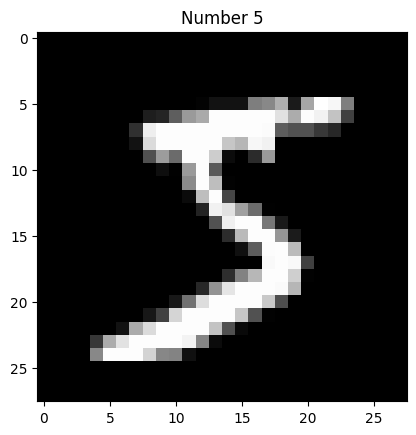

In [6]:
plt.imshow(train_data[0].reshape(28,28).detach().cpu(),cmap='gray');
plt.title(f'Number {str(train_label[0].item())}');

In [7]:
# 784 -> 250 -> 50 -> 250 -> 784, sigmoid output. Same as the denoising notebook.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 250)

    self.fc1 = nn.Linear(250,50)

    self.fc2 = nn.Linear(50,250)

    self.output_layer = nn.Linear(250,784)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    return  F.sigmoid(self.output_layer(x))

In [8]:
AutoEncoder = model().to('cuda')

output = AutoEncoder(train_data)

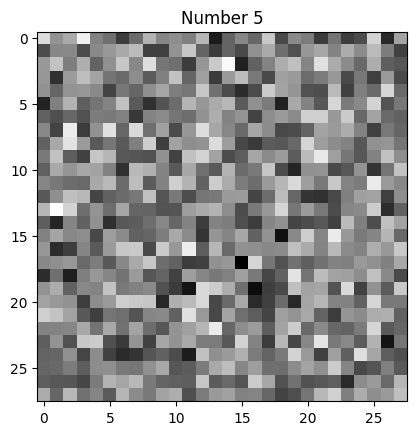

In [9]:
plt.imshow(output[0].reshape(28,28).detach().cpu(),cmap='gray');
plt.title(f'Number {str(train_label[0].item())}');

In [10]:
# Note the manual batching: a random permutation each epoch, then contiguous
# slices of it. Equivalent to a shuffled DataLoader, written out by hand.
# The slice runs batchi*bs to (batchi+1)*bs - starting at (batchi-1)*bs would
# make the first iteration index -32..0, silently wrapping around to the end of
# the array.
# Returns the mean of the last 3 epochs' losses - a smoothed final score rather
# than one noisy number.
def train_model():


  AutoEncoder = model().to('cuda')

  epochs = 5
  lr = 0.001

  lossFunc =  nn.MSELoss()
  optimizer = torch.optim.Adam(AutoEncoder.parameters(), lr=lr)

  train_acc = []
  losses = []

  bs = 32
  noBatches = int(train_data.shape[0]/bs)


  for i in range(epochs):

    randidx = np.random.permutation(train_data.shape[0]).astype(int)

    batch_losses = []

    for batchi in range(noBatches):

      samps2use = range(batchi*bs,(batchi+1)*bs)

      X = train_data[randidx[samps2use],:]

      AutoEncoder.train()

      yhat = AutoEncoder(X)
      loss = lossFunc(yhat,X) # We compare the loss with the inital input
      batch_losses.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    losses.append(np.mean(batch_losses) )
  return np.mean(losses[-3:]),AutoEncoder

In [11]:
losses , AutoEncoder = train_model()

In [12]:
# The final smoothed loss.
print(losses)

0.008834921837763653


In [13]:
# THE CORRUPTION: rows 10-12 set to white (1.0) across the full width.
# Note this reshapes to (N,28,28), edits, and reshapes back - the natural way to
# express a spatial edit on flattened data.
# The occlusion sits in the middle of the image, where most digits carry their
# distinguishing strokes.
subset = train_data[:10]

subset_reshaped = subset.reshape(-1, 28, 28)

subset_reshaped[:, 10:13, :] = 1

subset = subset_reshaped.reshape(-1, 784)

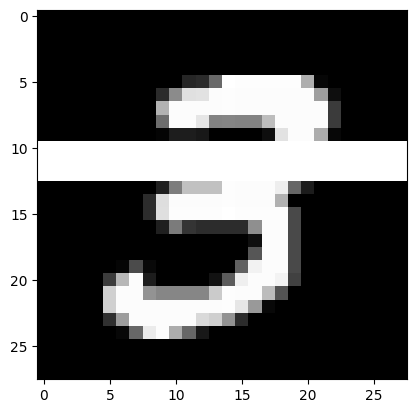

In [14]:
# An occluded digit - the bar cuts straight through it.
plt.imshow(subset[7].detach().cpu().reshape(28,28),cmap='gray');

Now testing the occluded set: 



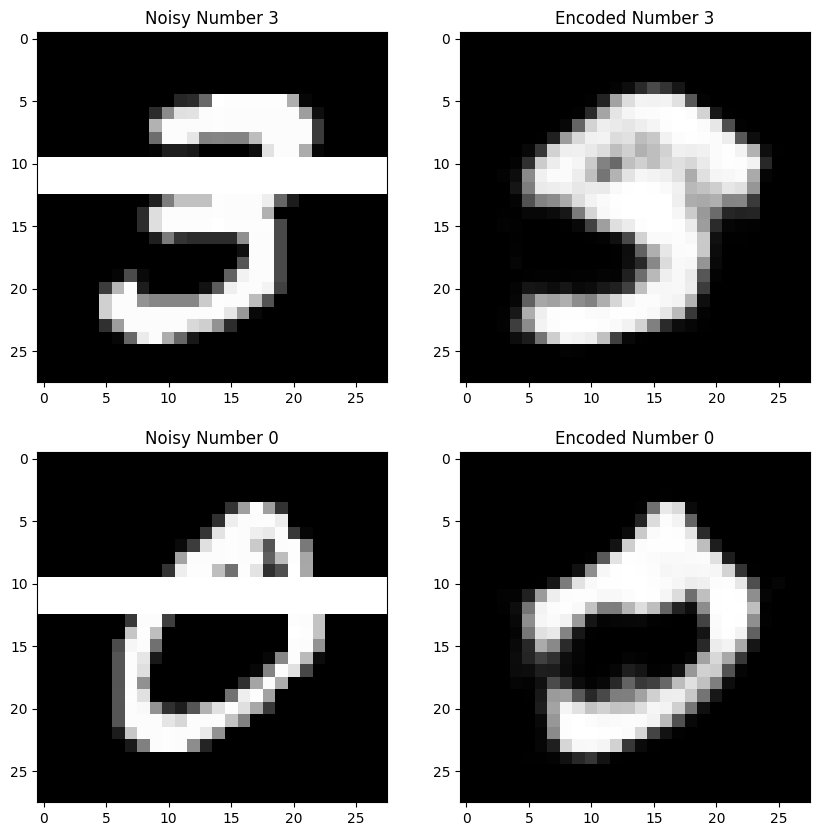

In [15]:
# Occluded input (left) vs reconstruction (right).
# Expect partial recovery: the bar softens and the digit partly returns, because
# the latent code says 'this is a 3' and the decoder draws a generic 3.
# But inpainting is genuinely harder than denoising - the information under the
# bar is gone, not merely obscured - and where the occlusion covers the stroke
# that distinguishes two digits, the model can reconstruct the wrong one
# confidently.
print("Now testing the occluded set: ")
print()

noisy_ouput = AutoEncoder(subset)

fig, ax = plt.subplots(2,2,figsize=(10,10))

ax[0, 0].imshow(subset[7].reshape(28,28).detach().cpu(),cmap='gray');
ax[0, 0].set_title(f'Noisy Number {str(train_label[7].item())}');

ax[0, 1].imshow(noisy_ouput[7].reshape(28,28).detach().cpu(),cmap='gray');
ax[0, 1].set_title(f'Encoded Number {str(train_label[7].item())}');

ax[1, 0].imshow(subset[1].reshape(28,28).detach().cpu(),cmap='gray');
ax[1, 0].set_title(f'Noisy Number {str(train_label[1].item())}');

ax[1, 1].imshow(noisy_ouput[1].reshape(28,28).detach().cpu(),cmap='gray');
ax[1, 1].set_title(f'Encoded Number {str(train_label[1].item())}');

## Conclusion

This notebook provided a practical introduction to Autoencoders using PyTorch and the MNIST dataset. We covered:

1.  **Data Preparation**: Loading the MNIST dataset, scaling pixel values, and converting them to PyTorch tensors for GPU acceleration.
2.  **Autoencoder Architecture**: Designing a simple feedforward Autoencoder with an input layer, hidden layers, and an output layer, demonstrating the encoding and decoding process.
3.  **Model Training**: Implementing the training loop with `nn.MSELoss` as the reconstruction loss and `torch.optim.Adam` for optimization, allowing the model to learn an efficient representation of the input data.
4.  **Reconstruction and Denoising**: Visualizing the model's ability to reconstruct original images and, importantly, its capacity to denoise corrupted images (occluded with white bars), showcasing a key application of Autoencoders in learning robust data representations.